In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # GERLIGERLI

# reads dataset and replaces linebreaks and missing values with ''
data = []
with open('../datasets/chronic_kidney_disease_full.arff', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        line = line.replace('?', '')
        line = line.replace('\t', '')
        data.append(line.split(','))

# gives names to the columns
names = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba',
         'bgr', 'bu',  'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc',
         'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
         'class', 'no_name']
    
df = pd.DataFrame(data[145:], columns=names)
# np.nan is recognised as missing value for Pandas functions e.g. isnull()
df = df.replace('', np.nan)

df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class,no_name
0,48,80,1.020,1,0,NaN,normal,notpresent,notpresent,121,...,7800,5.2,yes,yes,no,good,no,no,ckd,NaN
1,7,50,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,6000,NaN,no,no,no,good,no,no,ckd,NaN
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,7500,NaN,no,yes,no,poor,no,yes,ckd,NaN
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,NaN
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,7300,4.6,no,no,no,good,no,no,ckd,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,normal,normal,notpresent,notpresent,100,...,6600,5.4,no,no,no,good,no,no,notckd,NaN
398,17,60,1.025,0,0,normal,normal,notpresent,notpresent,114,...,7200,5.9,no,no,no,good,no,no,notckd,NaN
399,58,80,1.025,0,0,normal,normal,notpresent,notpresent,131,...,6800,6.1,no,no,no,good,no,no,notckd,NaN
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
# Drop unwanted columns
df.drop(columns=['rbc', 'pc','pcc','ba','sc','htn','dm','cad','appet','pe','ane', 'no_name'], inplace=True)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,15.4,44,7800,5.2,ckd
1,7,50,1.020,4,0,NaN,18,NaN,NaN,11.3,38,6000,NaN,ckd
2,62,80,1.010,2,3,423,53,NaN,NaN,9.6,31,7500,NaN,ckd
3,48,70,1.005,4,0,117,56,111,2.5,11.2,32,6700,3.9,ckd
4,51,80,1.010,2,0,106,26,NaN,NaN,11.6,35,7300,4.6,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,15.8,49,6600,5.4,notckd
398,17,60,1.025,0,0,114,50,135,4.9,14.2,51,7200,5.9,notckd
399,58,80,1.025,0,0,131,18,141,3.5,15.8,53,6800,6.1,notckd
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# converts hemoglobin values from g/dl to d/l by multiplying by 10
# original type (str) is first converted to float, multiplied and then converted back
df['hemo'] = df['hemo'].astype('Float64')
df['hemo'] = df['hemo'].apply(lambda x: x*10)
df['hemo'] = df['hemo'].astype(str)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,ckd
1,7,50,1.020,4,0,NaN,18,NaN,NaN,113.0,38,6000,NaN,ckd
2,62,80,1.010,2,3,423,53,NaN,NaN,96.0,31,7500,NaN,ckd
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,ckd
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,notckd
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,notckd
399,58,80,1.025,0,0,131,18,141,3.5,158.0,53,6800,6.1,notckd
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
# recodes class values 'ckd' and 'notckd' (chronic kidney disease, control) to 'a' and 'c'
df['class'] = df['class'].replace({'ckd':'a', 'notckd':'c'})
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,7,50,1.020,4,0,NaN,18,NaN,NaN,113.0,38,6000,NaN,a
2,62,80,1.010,2,3,423,53,NaN,NaN,96.0,31,7500,NaN,a
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c
399,58,80,1.025,0,0,131,18,141,3.5,158.0,53,6800,6.1,c
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
# remove rows with three or more missing values
df = df[df.isnull().sum(axis=1) < 3]
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
5,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
6,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
396,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


In [122]:
# reindex dataframe to correctly show the number of rows left
df = df.reset_index(drop=True)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
2,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
3,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
4,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
261,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
262,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
263,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


In [123]:
df_affected = df[df["class"] == "a"] #create a new data frame with filter that has only people with "a" in the class.
df_affected #display the new data generated.

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
2,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
3,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
4,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,62,90,1.020,2,1,169,48,138,2.9,134.0,47,11000,6.1,a
122,64,90,1.015,3,2,463,64,135,4.1,122.0,40,9800,4.6,a
123,48,110,1.015,3,0,106,215,120,5.7,86.0,26,5000,2.5,a
124,59,70,1.010,1,3,424,55,138,4.5,126.0,37,10200,4.1,a


In [124]:
df_controlled = df[df["class"] == "c"] #create a new data frame with filter that has only people with "c" in the class.
df_controlled #display the new data generated.

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
126,40,80,1.025,0,0,140,10,135,5.0,150.0,48,10400,4.5,c
127,23,80,1.025,0,0,70,36,150,4.6,170.0,52,9800,5.0,c
128,45,80,1.025,0,0,82,49,147,4.4,159.0,46,9100,4.7,c
129,57,80,1.025,0,0,119,17,135,4.7,154.0,42,6200,6.2,c
130,51,60,1.025,0,0,99,38,135,3.7,130.0,49,8300,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
261,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
262,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
263,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


In [125]:
df_affected.describe(include='all')

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,123,125,125,126,126,120,125,108,108,125,125,113,108,126
unique,45,8,5,6,6,95,83,27,35,68,31,71,36,1
top,65,70,1.010,0,0,107,24,136,4.0,113.0,32,9800,3.9,a
freq,9,34,52,32,85,3,4,12,10,5,10,8,10,126


In [126]:
df_controlled.describe(include='all')

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,138,136,138,138,138,134,134,135,135,136,137,135,135,138
unique,58,3,2,1,1,58,35,14,18,49,15,53,21,1
top,55,80,1.025,0,0,99,46,135,5.0,150.0,48,6700,4.5,c
freq,6,60,69,138,138,6,10,22,26,11,17,7,13,138


In [127]:
df_affected.bu.unique()

<ArrowStringArray>
[ '36',  '56',  '26',  '25',  '54',  '60', '107',  '72',  '90', '162',  '27',
  '31', '148', '163',  '50',  '75',  '45',  '87',  '33',  '39',  '29',  '70',
  '80', '202',  '77',  '24',  '32',  '66',   nan, '164', '142',  '15', '111',
  '20',  '19',  '92', '139',  '48',  '55',  '98', '186',  '47',  '35',  '82',
  '51', '217',  '53',  '71', '125', '166', '208',  '86', '106', '322', '235',
 '132',  '42',  '40',  '41', '113', '1.5',  '58', '153',  '52',  '23', '137',
  '67', '115', '223', '158',  '37',  '89',  '96', '150',  '73',  '30',  '61',
  '57',  '95', '191',  '46',  '64', '215', '309']
Length: 84, dtype: str

In [128]:
for df in [df_affected, df_controlled]:
    df['age'] = df['age'].astype('Int64')
    df['bp'] = df['bp'].astype('Int64')
    df['sg'] = df['sg'].astype('Float64')
    df['al'] = df['al'].astype('Int64')
    df['su'] = df['su'].astype('Int64')
    df['bgr'] = df['bgr'].astype('Int64')
    df['bu'] = df['bu'].astype('Float64')
    df['sod'] = df['sod'].astype('Int64')
    df['pot'] = df['pot'].astype('Float64')
    df['hemo'] = df['hemo'].astype('Float64')
    df['pcv'] = df['pcv'].astype('Int64')
    df['wbcc'] = df['wbcc'].astype('Int64')
    df['rbcc'] = df['age'].astype('Float64')
    

In [129]:
df_affected.dtypes

age        Int64
bp         Int64
sg       Float64
al         Int64
su         Int64
bgr        Int64
bu       Float64
sod        Int64
pot      Float64
hemo     Float64
pcv        Int64
wbcc       Int64
rbcc     Float64
class        str
dtype: object

In [130]:
df_controlled.dtypes

age        Int64
bp         Int64
sg       Float64
al         Int64
su         Int64
bgr        Int64
bu       Float64
sod        Int64
pot      Float64
hemo     Float64
pcv        Int64
wbcc       Int64
rbcc     Float64
class        str
dtype: object

In [102]:
df_affected[df_affected["bu"] == "1.5"]

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
88,17,70,1.015,1,0,22,1.5,145,2.8,131.0,41,11200,NaN,a


In [112]:
df_affected.wbcc.unique()

<ArrowStringArray>
[  '7800',   '6700',   '7300',      nan,   '9600',  '12100',   '4500',
  '12200',  '11000',   '3800',  '11400',   '5300',   '9200',   '6900',
   '8300',   '8400',  '10300',   '9800',   '9100',   '7900',   '6400',
  '18900',  '21600',   '8500',  '11300',   '7200',   '7700',  '14600',
   '6300', '\t6200',   '7100',  '11800',   '9400',   '5800',  '12500',
   '5600',   '7000',  '11900',  '10400',  '10700',  '12700',   '6800',
  '13600',  '10200',   '9000',   '5500',   '8200',  '15200',   '5000',
  '16300', '\t8400',   '6500',  '10500',   '4200',  '10900',   '8100',
   '9500',  '12800',  '11200',  '12400',  '19100',     '\t',   '7500',
  '16700',   '2600',  '26400',   '8800',   '7400',   '4900',   '8000',
  '12000',  '15700',  '11500',   '5400']
Length: 74, dtype: str

In [131]:
df_affected.describe(include='all')

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,123.0,125.0,125.0,126.0,126.0,120.0,125.0,108.0,108.0,125.0,125.0,113.0,123.0,126
unique,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
top,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,a
freq,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,126
mean,57.081301,80.72,1.01356,1.849206,0.809524,181.2,80.42,133.731481,4.751852,106.432,32.44,9450.442478,57.081301,NaN
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,14.465104,NaN
min,6.0,50.0,1.005,0.0,0.0,22.0,1.5,104.0,2.5,31.0,9.0,2600.0,6.0,NaN
25%,49.5,70.0,1.01,0.25,0.0,107.0,37.0,131.75,3.8,95.0,29.0,7100.0,49.5,NaN
50%,60.0,80.0,1.015,2.0,0.0,158.0,60.0,136.0,4.2,108.0,33.0,9200.0,60.0,NaN
75%,65.0,90.0,1.015,3.0,1.0,241.25,107.0,139.0,4.9,120.0,37.0,11000.0,65.0,NaN


In [132]:
df_controlled.describe(include='all')

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,138.0,136.0,138.0,138.0,138.0,134.0,134.0,135.0,135.0,136.0,137.0,135.0,138.0,138
unique,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
top,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,c
freq,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,138
mean,46.362319,71.323529,1.0225,0.0,0.0,107.38806,32.761194,141.718519,4.341481,152.0,46.248175,7688.888889,46.362319,NaN
std,15.774387,8.59016,0.002509,0.0,0.0,18.818049,11.44991,4.806171,0.594174,12.819545,4.122715,1808.011469,15.774387,NaN
min,12.0,60.0,1.02,0.0,0.0,70.0,10.0,135.0,3.3,130.0,40.0,4300.0,12.0,NaN
25%,34.0,60.0,1.02,0.0,0.0,93.0,23.25,138.0,3.7,141.0,43.0,6300.0,34.0,NaN
50%,46.0,70.0,1.0225,0.0,0.0,107.5,32.5,141.0,4.5,150.0,46.0,7400.0,46.0,NaN
75%,58.0,80.0,1.025,0.0,0.0,123.75,44.0,146.0,4.9,162.0,50.0,9200.0,58.0,NaN


In [144]:
def plot_data(df):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(df.select_dtypes(include=['Int64', 'Float64'])):
        plt.subplot(5, 3, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)

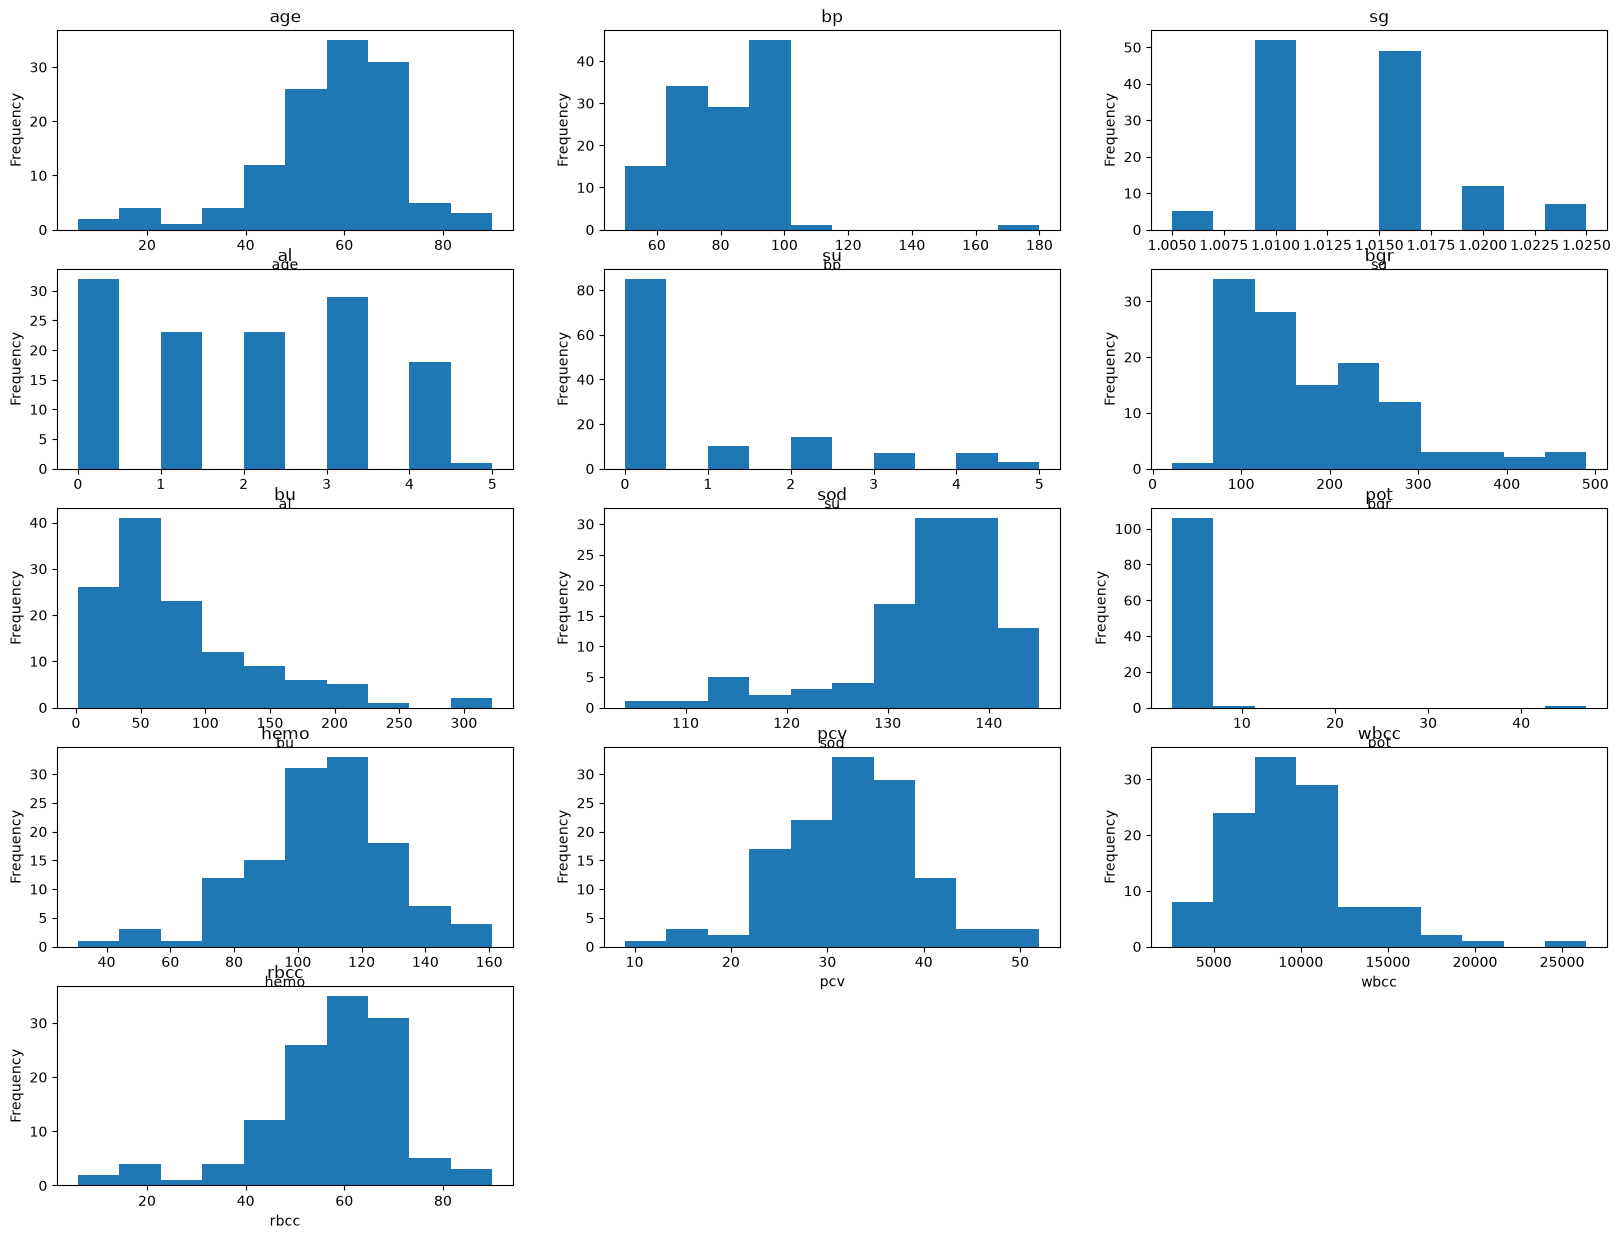

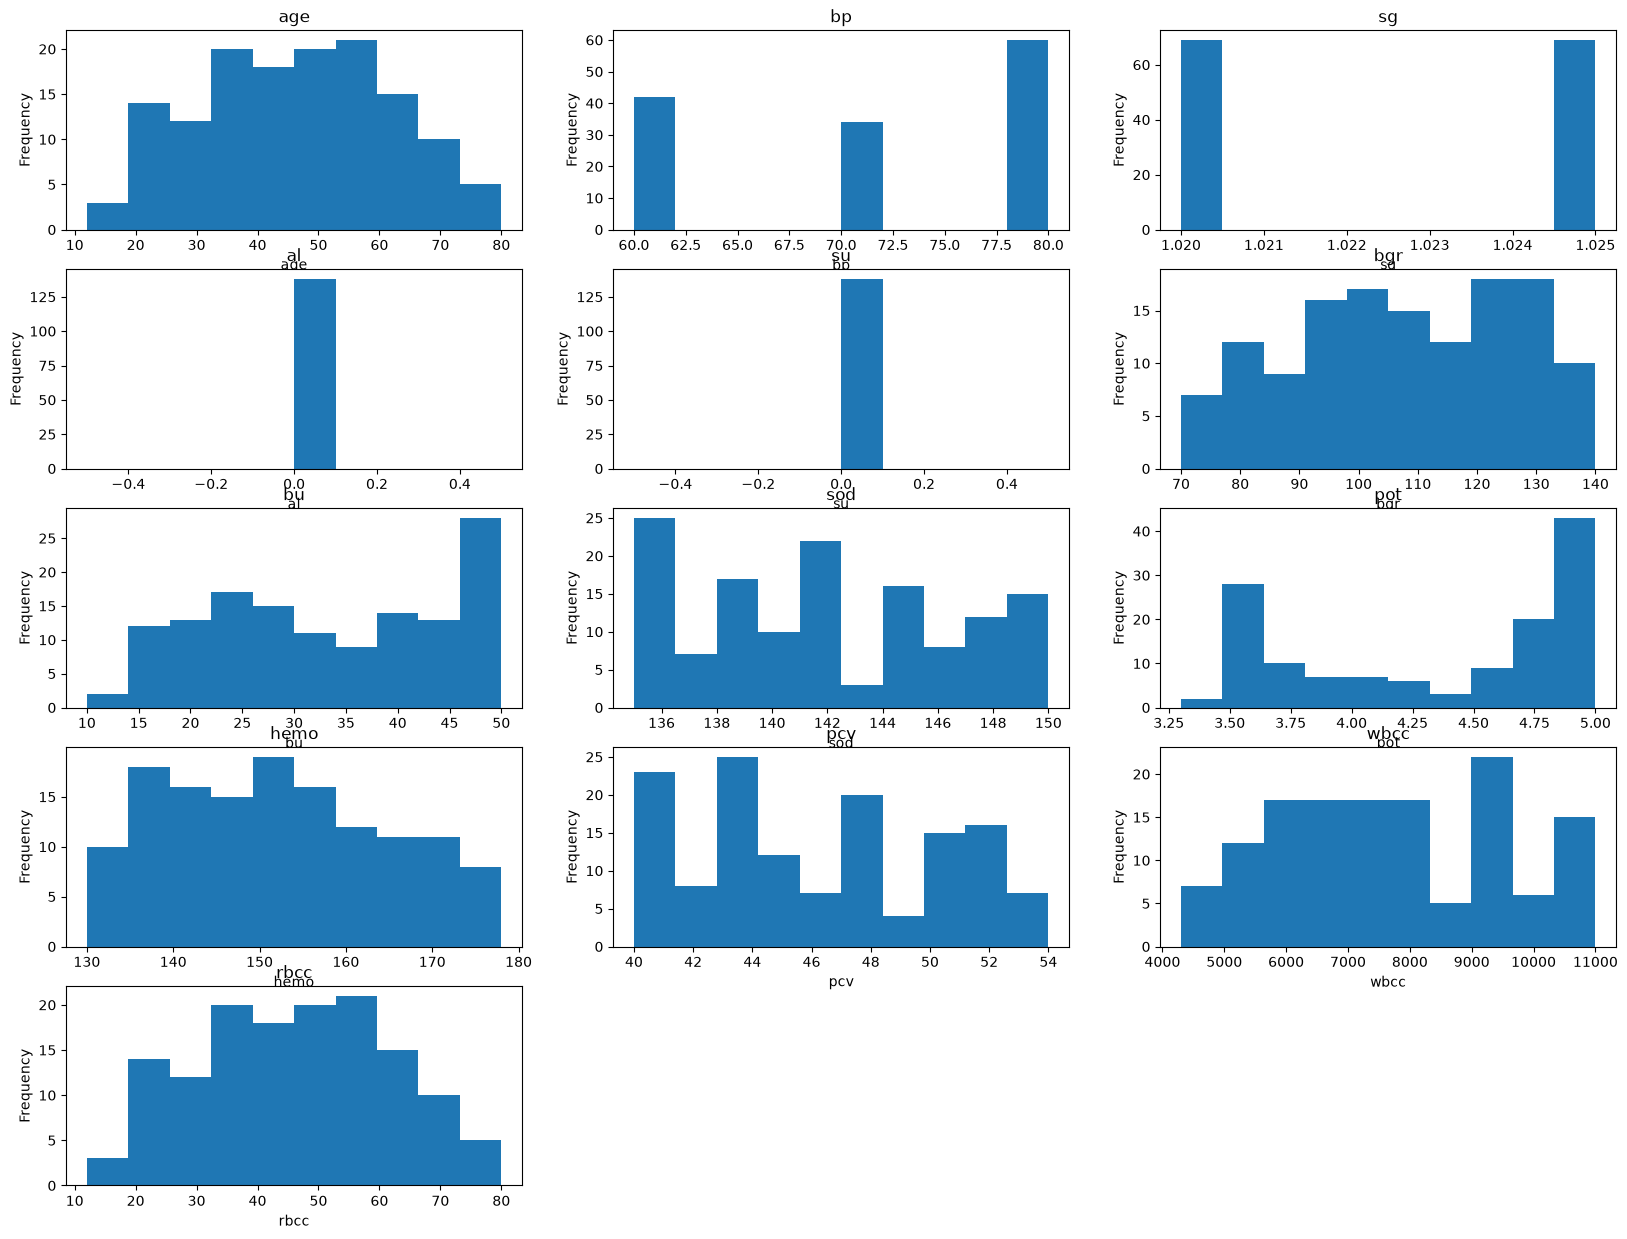

In [145]:
plot_data(df_affected)
plot_data(df_controlled)